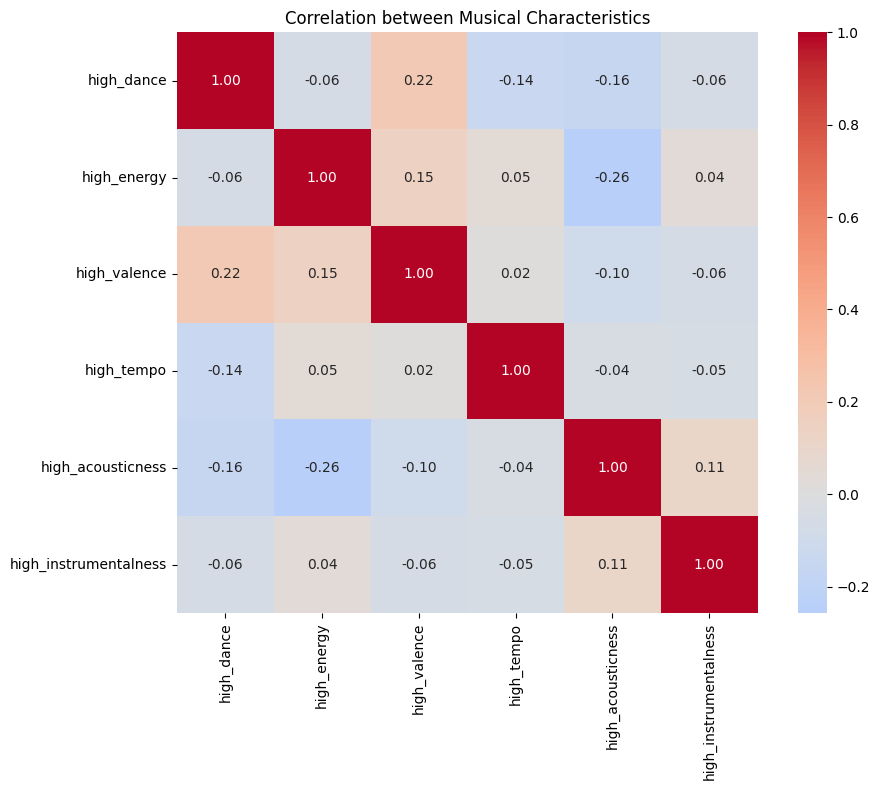

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



=== Top Musical Characteristic Patterns ===

These rules show which musical features tend to occur together:


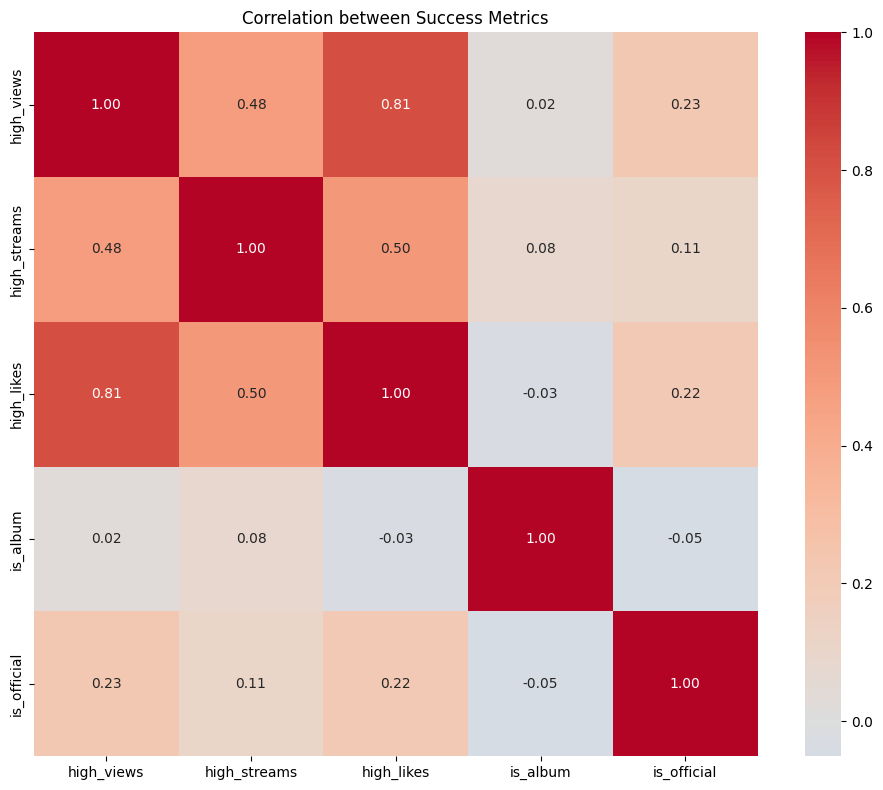


=== Top Success Patterns ===

These rules show what factors are associated with song success:

Pattern 114:
IF song has: ['is_album', 'is_official', 'high_likes']
THEN it likely has: ['high_streams', 'high_views']
Occurs in 10.8% of songs
Rule is correct 65.3% of the time
This is 4.3x more likely than random chance

Pattern 126:
IF song has: ['high_streams', 'high_views']
THEN it likely has: ['is_album', 'is_official', 'high_likes']
Occurs in 10.8% of songs
Rule is correct 70.8% of the time
This is 4.3x more likely than random chance

Pattern 118:
IF song has: ['high_streams', 'is_official', 'high_views']
THEN it likely has: ['is_album', 'high_likes']
Occurs in 10.8% of songs
Rule is correct 73.9% of the time
This is 4.2x more likely than random chance

Pattern 124:
IF song has: ['is_album', 'high_likes']
THEN it likely has: ['high_streams', 'is_official', 'high_views']
Occurs in 10.8% of songs
Rule is correct 61.8% of the time
This is 4.2x more likely than random chance

Pattern 65:


/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [35]:
## Lei(Raymond) Chi and 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Load and prepare data
df = pd.read_csv('Spotify_Youtube.csv')
url_cols = ['Unnamed: 0', 'Url_spotify', 'Uri', 'Url_youtube', 'Title', 'Description']
df.drop(url_cols, axis=1, inplace=True)
df.dropna(inplace=True)

# Create two separate binary feature sets
def create_musical_features(df):
    musical_df = pd.DataFrame()
    musical_df['high_dance'] = (df['Danceability'] > df['Danceability'].quantile(0.75)).astype(int)
    musical_df['high_energy'] = (df['Energy'] > df['Energy'].quantile(0.75)).astype(int)
    musical_df['high_valence'] = (df['Valence'] > df['Valence'].quantile(0.75)).astype(int)
    musical_df['high_tempo'] = (df['Tempo'] > df['Tempo'].quantile(0.75)).astype(int)
    musical_df['high_acousticness'] = (df['Acousticness'] > df['Acousticness'].quantile(0.75)).astype(int)
    musical_df['high_instrumentalness'] = (df['Instrumentalness'] > df['Instrumentalness'].quantile(0.75)).astype(int)
    return musical_df

def create_success_features(df):
    success_df = pd.DataFrame()
    success_df['high_views'] = (df['Views'] > df['Views'].quantile(0.75)).astype(int)
    success_df['high_streams'] = (df['Stream'] > df['Stream'].quantile(0.75)).astype(int)
    success_df['high_likes'] = (df['Likes'] > df['Likes'].quantile(0.75)).astype(int)
    success_df['is_album'] = (df['Album_type'] == 'album').astype(int)
    success_df['is_official'] = (df['official_video'] == True).astype(int)
    return success_df

# Create separate feature sets
musical_df = create_musical_features(df)
success_df = create_success_features(df)

# Analysis 1: Musical Characteristics
plt.figure(figsize=(10, 8))
sns.heatmap(musical_df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation between Musical Characteristics')
plt.tight_layout()
plt.show()

# Generate rules for musical characteristics
musical_itemsets = apriori(musical_df, min_support=0.1, use_colnames=True)
musical_rules = association_rules(musical_itemsets, 
                                metric="confidence",
                                min_threshold=0.5,
                                num_itemsets=len(musical_itemsets))
musical_rules = musical_rules.sort_values('lift', ascending=False)

print("\n=== Top Musical Characteristic Patterns ===")
print("\nThese rules show which musical features tend to occur together:")
for idx, row in musical_rules.head(5).iterrows():
    print(f"\nPattern {idx+1}:")
    print(f"IF song has: {list(row['antecedents'])}")
    print(f"THEN it likely has: {list(row['consequents'])}")
    print(f"Occurs in {row['support']:.1%} of songs")
    print(f"Rule is correct {row['confidence']:.1%} of the time")
    print(f"This is {row['lift']:.1f}x more likely than random chance")

# Analysis 2: Success Metrics
plt.figure(figsize=(10, 8))
sns.heatmap(success_df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Correlation between Success Metrics')
plt.tight_layout()
plt.show()

# Generate rules for success metrics
success_itemsets = apriori(success_df, min_support=0.1, use_colnames=True)
success_rules = association_rules(success_itemsets, 
                                metric="confidence",
                                min_threshold=0.5,
                                num_itemsets=len(success_itemsets))
success_rules = success_rules.sort_values('lift', ascending=False)

print("\n=== Top Success Patterns ===")
print("\nThese rules show what factors are associated with song success:")
for idx, row in success_rules.head(5).iterrows():
    print(f"\nPattern {idx+1}:")
    print(f"IF song has: {list(row['antecedents'])}")
    print(f"THEN it likely has: {list(row['consequents'])}")
    print(f"Occurs in {row['support']:.1%} of songs")
    print(f"Rule is correct {row['confidence']:.1%} of the time")
    print(f"This is {row['lift']:.1f}x more likely than random chance")

In [42]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def create_music_features(df):
    """Create meaningful binary features for music market basket analysis."""
    features = pd.DataFrame()
    
    # Convert all features to explicit boolean first
    features['high_energy'] = df['Energy'] > df['Energy'].median()
    features['high_danceability'] = df['Danceability'] > df['Danceability'].median()
    features['high_valence'] = df['Valence'] > df['Valence'].median()
    features['high_acousticness'] = df['Acousticness'] > df['Acousticness'].median()
    features['high_instrumentalness'] = df['Instrumentalness'] > df['Instrumentalness'].median()
    features['high_liveness'] = df['Liveness'] > df['Liveness'].median()
    features['high_speechiness'] = df['Speechiness'] > df['Speechiness'].median()
    
    # Success metrics
    features['high_views'] = df['Views'] > df['Views'].median()
    features['high_streams'] = df['Stream'] > df['Stream'].median()
    features['viral_hit'] = (df['Views'] > df['Views'].quantile(0.9)) & (df['Stream'] > df['Stream'].quantile(0.9))
    
    # Technical features
    features['long_duration'] = df['Duration_ms'] > df['Duration_ms'].median()
    features['fast_tempo'] = df['Tempo'] > df['Tempo'].median()
    
    # Release strategy
    features['is_album'] = df['Album_type'] == 'album'
    features['is_official'] = df['official_video']
    
    # Convert everything to integers (1/0) for the market basket analysis
    features = features.astype(int)
    
    return features

def analyze_patterns(df, min_support=0.1, min_confidence=0.5, min_lift=1.5):
    """Perform market basket analysis on the features."""
    # Generate frequent itemsets
    frequent_itemsets = apriori(df, 
                               min_support=min_support, 
                               use_colnames=True)
    
    if len(frequent_itemsets) == 0:
        print("No frequent itemsets found. Try lowering the minimum support threshold.")
        return pd.DataFrame()
    
    # Generate rules
    rules = association_rules(frequent_itemsets, 
                            metric="confidence", 
                            min_threshold=min_confidence)
    
    # Filter rules by lift
    rules = rules[rules['lift'] >= min_lift]
    
    # Sort by lift and confidence
    rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])
    
    return rules

def print_insights(rules, n_rules=5):
    """Print the discovered patterns in a readable format."""
    if len(rules) == 0:
        print("No significant patterns found.")
        return
        
    print("\n=== Most Significant Music Patterns ===\n")
    for idx, row in rules.head(n_rules).iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])
        
        print(f"Pattern {idx+1}:")
        print(f"IF song has: {antecedents}")
        print(f"THEN it likely has: {consequents}")
        print(f"Occurs in {row['support']:.1%} of songs")
        print(f"Rule is correct {row['confidence']:.1%} of the time")
        print(f"This is {row['lift']:.1f}x more likely than random chance\n")

# Example usage
if __name__ == "__main__":
    # Load and clean data
    df = pd.read_csv('Spotify_Youtube.csv')
    url_cols = ['Unnamed: 0', 'Url_spotify', 'Uri', 'Url_youtube', 'Title', 'Description']
    df.drop(url_cols, axis=1, inplace=True)
    df.dropna(inplace=True)
    
    # Create features
    features_df = create_music_features(df)
    
    # Look at the created features
    print("Features created (first 5 rows):")
    print(features_df.head())
    print("\nFeature distribution (percentage of 1s):")
    print((features_df.mean() * 100).round(1))
    
    # Find patterns
    print("\nFinding patterns...")
    patterns = analyze_patterns(features_df, 
                              min_support=0.05,  # Lowered to find more patterns
                              min_confidence=0.5,
                              min_lift=1.5)
    
    # Print insights
    print_insights(patterns, n_rules=10)

Features created (first 5 rows):
   high_energy  high_danceability  high_valence  high_acousticness  \
0            1                  1             1                  0   
1            1                  1             1                  0   
2            1                  1             1                  0   
3            1                  1             1                  0   
4            1                  1             0                  0   

   high_instrumentalness  high_liveness  high_speechiness  high_views  \
0                      1              1                 1           1   
1                      1              0                 0           1   
2                      1              0                 1           0   
3                      1              0                 0           1   
4                      0              0                 1           1   

   high_streams  viral_hit  long_duration  fast_tempo  is_album  is_official  
0             1          1  

/Users/raymondchi/.pyenv/versions/3.11.0/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


TypeError: association_rules() missing 1 required positional argument: 'num_itemsets'

In [ ]:
import pandas as pd
import numpy as np

# Assuming you already have your data loaded
df = pd.read_csv('Spotify_Youtube.csv')
url_cols = ['Unnamed: 0', 'Url_spotify', 'Uri', 'Url_youtube', 'Title', 'Description']
df.drop(url_cols, axis=1, inplace=True)
df.dropna(inplace=True)

# Create the features using our function
features_df = create_music_features(df)

# Let's look at the first few rows and the structure
print("Shape of features DataFrame:", features_df.shape)
print("\nColumns in features DataFrame:", features_df.columns.tolist())
print("\nFirst few rows of the features DataFrame:")
print(features_df.head())

# Let's also see the distribution of our binary features
print("\nFeature distribution (percentage of 1s):")
feature_distribution = features_df.mean().round(3) * 100
for feature, percentage in feature_distribution.items():
    print(f"{feature}: {percentage}%")

TypeError: argument of type 'method' is not iterable